# 03 Feature Engineering

This notebook converts the processed customer churn dataset into machine-learning-ready features.

The objectives are to:

- load the processed dataset
- separate predictors and target
- encode categorical variables
- perform a stratified 70/30 train-validation split
- handle class imbalance in the training set
- export machine-learning-ready datasets for model development

These steps correspond to the modelling preparation stage in the original SAS Viya workflow, where stratified partitioning and event-based sampling were used before model training.

## 1. Import Libraries

In [57]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load Processed Dataset

The processed dataset created in Notebook 2 is loaded from the `data/processed/` directory.

In [58]:
DATA_PATH = "../data/processed/customer_churn_processed.csv"

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()

Rows: 10,127
Columns: 25


,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn,Education_Group,Income_Group,LOG_Credit_Limit,LOG_Avg_Open_To_Buy,LOG_Avg_Utilization_Ratio
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0,Low Education,Middle Income,9.448727,9.385553,0.059212
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0,Medium Education,Low Income,9.018817,8.908289,0.099845
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0,Medium Education,Middle Income,8.137103,8.137103,0.000000
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0,Low Education,Low Income,8.105911,6.680855,0.565314
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0,Low Education,Middle Income,8.458928,8.458928,0.000000


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_Age               10127 non-null  int64  
 1   Gender                     10127 non-null  str    
 2   Dependent_count            10127 non-null  int64  
 3   Education_Level            10127 non-null  str    
 4   Marital_Status             10127 non-null  str    
 5   Income_Category            10127 non-null  str    
 6   Card_Category              10127 non-null  str    
 7   Months_on_book             10127 non-null  int64  
 8   Total_Relationship_Count   10127 non-null  int64  
 9   Months_Inactive_12_mon     10127 non-null  int64  
 10  Contacts_Count_12_mon      10127 non-null  int64  
 11  Credit_Limit               10127 non-null  float64
 12  Total_Revolving_Bal        10127 non-null  int64  
 13  Avg_Open_To_Buy            10127 non-null  float64
 14  T

## 3. Separate Predictors and Target

The target variable is `Churn`.

- `Churn = 1` indicates an attrited customer.
- `Churn = 0` indicates an existing customer.

All other columns are treated as candidate predictors.

In [60]:
target = "Churn"

X = df.drop(columns=[target])
y = df[target]

print(f"Predictor shape: {X.shape}")
print(f"Target shape: {y.shape}")

Predictor shape: (10127, 24)
Target shape: (10127,)


## Predictor Representation Strategy

To avoid redundant information and multicollinearity, this notebook retains the engineered grouped and log-transformed variables while removing their original source variables.

The following original variables are removed:

- `Education_Level`
- `Income_Category`
- `Credit_Limit`
- `Avg_Open_To_Buy`
- `Avg_Utilization_Ratio`

This avoids modelling duplicated information, since:

- `Education_Group` and `Income_Group` represent consolidated versions of the original categorical variables.
- `LOG_Credit_Limit`, `LOG_Avg_Open_To_Buy`, and `LOG_Avg_Utilization_Ratio` represent transformed versions of the original skewed variables.

`Marital_Status` is retained because no grouped replacement variable was created for it.

In [61]:
redundant_features = [
    "Education_Level",
    "Income_Category",
    "Credit_Limit",
    "Avg_Open_To_Buy",
    "Avg_Utilization_Ratio"
]

X = X.drop(columns=redundant_features)

print(f"Predictor shape after removing redundant features: {X.shape}")
X.head()

Predictor shape after removing redundant features: (10127, 19)


,Customer_Age,Gender,Dependent_count,Marital_Status,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Education_Group,Income_Group,LOG_Credit_Limit,LOG_Avg_Open_To_Buy,LOG_Avg_Utilization_Ratio
0,45,M,3,Married,Blue,39,5,1,3,777,1.335,1144,42,1.625,Low Education,Middle Income,9.448727,9.385553,0.059212
1,49,F,5,Single,Blue,44,6,1,2,864,1.541,1291,33,3.714,Medium Education,Low Income,9.018817,8.908289,0.099845
2,51,M,3,Married,Blue,36,4,1,0,0,2.594,1887,20,2.333,Medium Education,Middle Income,8.137103,8.137103,0.000000
3,40,F,4,Unknown,Blue,34,3,4,1,2517,1.405,1171,20,2.333,Low Education,Low Income,8.105911,6.680855,0.565314
4,40,M,3,Married,Blue,21,5,1,0,0,2.175,816,28,2.500,Low Education,Middle Income,8.458928,8.458928,0.000000


## 4. Target Class Balance

Before modelling, the target distribution is reviewed to understand class imbalance.

In [62]:
target_distribution = (
    y.value_counts()
    .reset_index()
)

target_distribution.columns = ["Churn", "Count"]

target_distribution["Percentage"] = (
    target_distribution["Count"] / len(y) * 100
).round(2)

target_distribution

,Churn,Count,Percentage
0,0,8500,83.93
1,1,1627,16.07


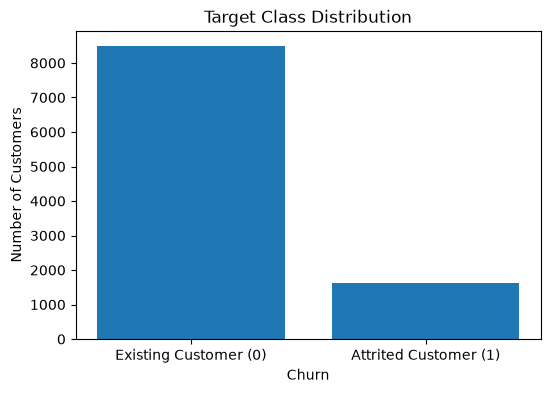

In [63]:
plt.figure(figsize=(6, 4))

plt.bar(
    target_distribution["Churn"].astype(str),
    target_distribution["Count"]
)

plt.title("Target Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Existing Customer (0)", "Attrited Customer (1)"])

plt.show()

### Class Balance Findings

The dataset is imbalanced, with existing customers forming the majority class and attrited customers forming the minority class.

This mirrors the class imbalance addressed in the original SAS Viya workflow using event-based sampling.

## 5. Identify Numerical and Categorical Features

Machine learning models require categorical variables to be converted into numerical representations.

This section separates numerical and categorical predictors before encoding.

In [64]:
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

feature_type_summary = pd.DataFrame({
    "Feature Type": ["Categorical", "Numerical"],
    "Count": [len(categorical_features), len(numerical_features)]
})

display(feature_type_summary)

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

,Feature Type,Count
0,Categorical,5
1,Numerical,14


Categorical features:
['Gender', 'Marital_Status', 'Card_Category', 'Education_Group', 'Income_Group']

Numerical features:
['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'LOG_Credit_Limit', 'LOG_Avg_Open_To_Buy', 'LOG_Avg_Utilization_Ratio']


## 6. One-Hot Encoding

Categorical variables are converted into numerical dummy variables using one-hot encoding.

All category levels are retained using `drop_first=False`. This is appropriate because the modelling stage includes tree-based algorithms such as Decision Tree, Random Forest, and Gradient Boosting, which are not affected by the dummy-variable trap in the same way as linear models.

For Logistic Regression and SVM, multicollinearity may be considered during model development if needed.

In [65]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=False
)

print(f"Original predictor columns after redundancy removal: {X.shape[1]}")
print(f"Encoded predictor columns: {X_encoded.shape[1]}")
print(f"Additional dummy columns created: {X_encoded.shape[1] - X.shape[1]}")

X_encoded.head()

Original predictor columns after redundancy removal: 19
Encoded predictor columns: 32
Additional dummy columns created: 13


,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,LOG_Credit_Limit,LOG_Avg_Open_To_Buy,LOG_Avg_Utilization_Ratio,Gender_F,Gender_M,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Education_Group_High Education,Education_Group_Low Education,Education_Group_Medium Education,Education_Group_Unknown,Income_Group_High Income,Income_Group_Low Income,Income_Group_Middle Income,Income_Group_Unknown
0,45,3,39,5,1,3,777,1.335,1144,42,1.625,9.448727,9.385553,0.059212,False,True,False,True,False,False,True,False,False,False,False,True,False,False,False,False,True,False
1,49,5,44,6,1,2,864,1.541,1291,33,3.714,9.018817,8.908289,0.099845,True,False,False,False,True,False,True,False,False,False,False,False,True,False,False,True,False,False
2,51,3,36,4,1,0,0,2.594,1887,20,2.333,8.137103,8.137103,0.000000,False,True,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False
3,40,4,34,3,4,1,2517,1.405,1171,20,2.333,8.105911,6.680855,0.565314,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,True,False,False
4,40,3,21,5,1,0,0,2.175,816,28,2.500,8.458928,8.458928,0.000000,False,True,False,True,False,False,True,False,False,False,False,True,False,False,False,False,True,False


In [66]:
encoded_feature_summary = pd.DataFrame({
    "Stage": [
        "After Redundancy Removal",
        "After One-Hot Encoding"
    ],
    "Number of Features": [
        X.shape[1],
        X_encoded.shape[1]
    ],
    "Change": [
        "-",
        f"+{X_encoded.shape[1] - X.shape[1]} dummy variables"
    ]
})

encoded_feature_summary

,Stage,Number of Features,Change
0,After Redundancy Removal,19,-
1,After One-Hot Encoding,32,+13 dummy variables


### Encoding Findings

One-hot encoding increases the number of predictor columns because each categorical level is represented as a separate binary feature.

This produces a fully numerical feature matrix suitable for model training.

## 7. Train-Validation Split

The original SAS Viya modelling workflow used a 70/30 stratified partition.

The same approach is reproduced in Python:

- 70% training set
- 30% validation set
- stratification by `Churn` to preserve class proportions

In [67]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_encoded,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_valid shape: {y_valid.shape}")

X_train shape: (7088, 32)
X_valid shape: (3039, 32)
y_train shape: (7088,)
y_valid shape: (3039,)


A fixed random seed (random_state=42) is used to ensure reproducible data partitioning.

In [68]:
split_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation"],
    "Rows": [len(X_train), len(X_valid)],
    "Percentage": [
        round(len(X_train) / len(X_encoded) * 100, 2),
        round(len(X_valid) / len(X_encoded) * 100, 2)
    ],
    "Churn Rate (%)": [
        round(y_train.mean() * 100, 2),
        round(y_valid.mean() * 100, 2)
    ]
})

split_summary

,Dataset,Rows,Percentage,Churn Rate (%)
0,Training,7088,69.99,16.07
1,Validation,3039,30.01,16.06


### Split Findings

The stratified split preserves the churn rate across both training and validation sets.

This ensures that model evaluation is performed on a validation set that reflects the original target distribution.

## 8. Class Imbalance Handling

The original SAS Viya workflow applied event-based sampling to create a more balanced training set.

In this Python implementation, random oversampling is applied to the training set only. This approach was selected because it closely mirrors SAS Viya's event-based sampling strategy while keeping the workflow simple and reproducible.

The validation set is left unchanged to provide a realistic evaluation of model performance on the original class distribution.

In [69]:
train_data = X_train.copy()
train_data["Churn"] = y_train.values

majority_class = train_data[train_data["Churn"] == 0]
minority_class = train_data[train_data["Churn"] == 1]

print(f"Majority class rows: {len(majority_class):,}")
print(f"Minority class rows: {len(minority_class):,}")

Majority class rows: 5,949
Minority class rows: 1,139


In [70]:
minority_oversampled = minority_class.sample(
    n=len(majority_class),
    replace=True,
    random_state=42
)

train_balanced = pd.concat(
    [majority_class, minority_oversampled],
    axis=0
).sample(frac=1, random_state=42)

X_train_balanced = train_balanced.drop(columns=["Churn"])
y_train_balanced = train_balanced["Churn"]

print(f"Balanced training feature shape: {X_train_balanced.shape}")
print(f"Balanced training target shape: {y_train_balanced.shape}")

Balanced training feature shape: (11898, 32)
Balanced training target shape: (11898,)


In [71]:
balance_comparison = pd.DataFrame({
    "Dataset": [
        "Original Training",
        "Original Training",
        "Balanced Training",
        "Balanced Training",
        "Validation",
        "Validation"
    ],
    "Class": [
        "Existing Customer (0)",
        "Attrited Customer (1)",
        "Existing Customer (0)",
        "Attrited Customer (1)",
        "Existing Customer (0)",
        "Attrited Customer (1)"
    ],
    "Count": [
        (y_train == 0).sum(),
        (y_train == 1).sum(),
        (y_train_balanced == 0).sum(),
        (y_train_balanced == 1).sum(),
        (y_valid == 0).sum(),
        (y_valid == 1).sum()
    ]
})

balance_comparison

,Dataset,Class,Count
0,Original Training,Existing Customer (0),5949
1,Original Training,Attrited Customer (1),1139
2,Balanced Training,Existing Customer (0),5949
3,Balanced Training,Attrited Customer (1),5949
4,Validation,Existing Customer (0),2551
5,Validation,Attrited Customer (1),488


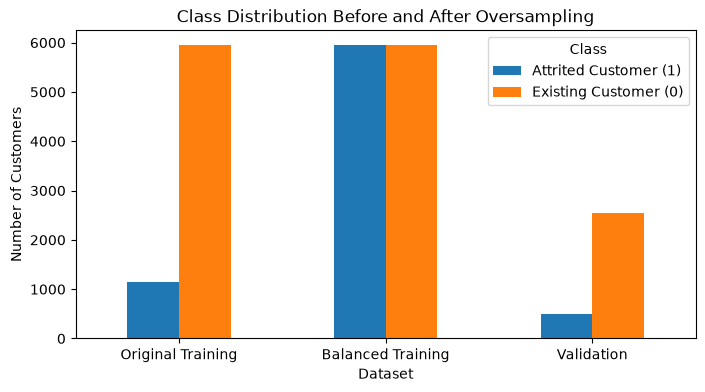

In [72]:
balance_pivot = balance_comparison.pivot(
    index="Dataset",
    columns="Class",
    values="Count"
)

balance_pivot = balance_pivot.loc[
    ["Original Training", "Balanced Training", "Validation"]
]

balance_pivot.plot(kind="bar", figsize=(8, 4))

plt.title("Class Distribution Before and After Oversampling")
plt.xlabel("Dataset")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Class")

plt.show()

### Class Imbalance Treatment Findings

Random oversampling creates a balanced training set with equal representation of churned and non-churned customers.

Only the training set is oversampled. The validation set remains unchanged to provide an unbiased evaluation of model performance on the original class distribution.

## 9. Feature Alignment Check

Before exporting the feature matrices, the training and validation datasets are checked to ensure they contain the same columns in the same order.

In [74]:
same_columns = list(X_train_balanced.columns) == list(X_valid.columns)

print(f"Training and validation columns aligned: {same_columns}")
print(f"Number of features: {X_train_balanced.shape[1]}")

Training and validation columns aligned: True
Number of features: 32


## Feature Name Export

The final encoded feature names are exported for later model interpretation, including feature importance and SHAP analysis.

In [73]:
feature_names = pd.DataFrame({
    "Feature": X_train_balanced.columns
})

feature_names.to_csv("../data/processed/feature_names.csv", index=False)

feature_names.head()

,Feature
0,Customer_Age
1,Dependent_count
2,Months_on_book
3,Total_Relationship_Count
4,Months_Inactive_12_mon


## 10. Feature Engineering Summary

In [75]:
feature_engineering_summary = pd.DataFrame({
    "Item": [
        "Original processed rows",
        "Original processed columns",
        "Predictor columns after redundancy removal",
        "Encoded feature columns",
        "Training rows before balancing",
        "Training rows after balancing",
        "Validation rows",
        "Original churn rate",
        "Balanced training churn rate",
        "Validation churn rate"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        X.shape[1],
        X_encoded.shape[1],
        X_train.shape[0],
        X_train_balanced.shape[0],
        X_valid.shape[0],
        f"{y.mean() * 100:.2f}%",
        f"{y_train_balanced.mean() * 100:.2f}%",
        f"{y_valid.mean() * 100:.2f}%"
    ]
})

feature_engineering_summary

,Item,Value
0,Original processed rows,10127
1,Original processed columns,25
2,Predictor columns after redundancy removal,19
3,Encoded feature columns,32
4,Training rows before balancing,7088
5,Training rows after balancing,11898
6,Validation rows,3039
7,Original churn rate,16.07%
8,Balanced training churn rate,50.00%
9,Validation churn rate,16.06%


## 11. Export Machine-Learning-Ready Datasets

The feature-engineered datasets are exported for use in the model development notebook.

The following files are created:

- `X_train_balanced.csv`
- `y_train_balanced.csv`
- `X_valid.csv`
- `y_valid.csv`
- `feature_names.csv`

In [77]:
X_train_balanced.to_csv("../data/processed/X_train_balanced.csv", index=False)
y_train_balanced.to_csv("../data/processed/y_train_balanced.csv", index=False)

X_valid.to_csv("../data/processed/X_valid.csv", index=False)
y_valid.to_csv("../data/processed/y_valid.csv", index=False)

print("Machine-learning-ready datasets successfully exported.")
print(f"X_train_balanced: {X_train_balanced.shape}")
print(f"y_train_balanced: {y_train_balanced.shape}")
print(f"X_valid: {X_valid.shape}")
print(f"y_valid: {y_valid.shape}")

Machine-learning-ready datasets successfully exported.
X_train_balanced: (11898, 32)
y_train_balanced: (11898,)
X_valid: (3039, 32)
y_valid: (3039,)


## 12. Final Summary

This notebook prepared the processed churn dataset for machine learning.

Key steps completed:

- Separated predictors and target
- Removed redundant original variables after grouped and log-transformed versions were created
- Reviewed class imbalance
- Identified numerical and categorical predictors
- Applied one-hot encoding to categorical variables
- Retained all dummy categories using `drop_first=False`
- Reproduced the SAS Viya 70/30 stratified partition strategy
- Applied random oversampling to balance the training set
- Preserved the validation set in its original distribution
- Verified feature alignment between training and validation sets
- Exported machine-learning-ready datasets and feature names for model development

The next notebook will train and compare multiple classification models, including Decision Tree, Random Forest, Gradient Boosting, SVM, and Logistic Regression.